# Attractive but Hard to Get
## Sections 2-4: Where critical minerals are, and why supply chains can't easily diversify

---

> *The raw materials for the energy transition exist on every continent. So does the knowledge to extract them. Yet a single country controls the refining of nearly all of them, a handful of nations hold the only viable orebodies for several, and hundreds of mapped deposits will never see a shovel - because the economics don't work, or the politics won't allow it. This chapter explains the geological and industrial barriers.*

---

In [25]:
import os
os.environ.pop('MPLBACKEND', None)

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path

DARK_BG   = '#16213e'
PANEL_BG  = '#1a1a2e'
ACCENT    = '#f0a500'
MUTED     = '#888888'
CHINA_RED = '#DE2910'
DRC_BLUE  = '#007FFF'
SA_GREEN  = '#007A4D'
AUS_GOLD  = '#FFD700'

COUNTRY_COLORS = {
    'China': CHINA_RED, 'DRC': DRC_BLUE, 'South Africa': SA_GREEN,
    'Australia': AUS_GOLD, 'Chile': '#00b4d8',
    'United States': '#3C3B6E', 'Other': MUTED,
}

plt.rcParams.update({
    'figure.dpi': 130, 'axes.facecolor': PANEL_BG, 'figure.facecolor': DARK_BG,
    'axes.edgecolor': '#444', 'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white', 'axes.titlecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.15, 'grid.color': '#555',
})

RAW  = Path('../../data/data/raw')
PROC = Path('../../data/data/processed')

df_eu     = pd.read_csv(RAW / 'D+ USGS MCS 2025' / 'mcs2025_all_end_uses.csv', comment='#')
df_china  = pd.read_csv(RAW / 'E USGS Fact Sheet Mining vs Processing' / 'china_mining_vs_processing_summary.csv', comment='#')
df_mvp    = pd.read_csv(RAW / 'E USGS Fact Sheet Mining vs Processing' / 'mining_vs_processing_extracted.csv', comment='#')
df_owid   = pd.read_csv(RAW / 'C OWID Mine Production' / 'global-mine-production-minerals.csv')
df_owid.rename(columns={df_owid.columns[2]: 'production'}, inplace=True)
gdf_world = gpd.read_file(RAW / 'G Natural Earth' / 'ne_110m_admin_0_sovereignty.shp')

TYPE_I  = ['Copper', 'Lithium', 'Graphite', 'Neodymium']
TYPE_II = ['Cobalt', 'Dysprosium', 'Terbium', 'Gallium', 'Platinum']

print('Setup complete.')

Setup complete.


---
## Section 2 — Where They Are
### The Geology: Deposits exist globally, but that's only the first quarter of the story

The USGS has mapped more than 13,000 critical mineral deposit locations globally. On paper, deposits exist on every continent — copper in South America and southern Africa, lithium in the Atacama and Australia, graphite in multiple countries, rare earth elements from Greenland to Brazil to Kazakhstan.

But geology is not the same as supply. The raw materials exist globally, yet a handful of countries — and in several cases, just one — hold decisive leverage. This is not an accident of nature; it reflects four distinct types of barriers, each with different timescales and policy solutions.

---

---
### Three structural types: why a deposit on a map is not the same as supply

The deposit map shows critical minerals on every continent. But a deposit is not supply. Between ore in the ground and usable material in a factory lies a chain of extraction, processing, and refinement — and that chain can concentrate in ways that geology never did. Three distinct structural patterns explain how materials that appear geographically abundant can still be practically inaccessible:

> **Type 1 — Abundant but Captive.** Ore bodies are geologically distributed and mining is reasonably spread across countries. The bottleneck is downstream: processing capacity has concentrated in the hands of one or a few actors through deliberate investment, industrial policy, or decades of accumulated expertise. The ore is available; access to the finished, usable material is not.

> **Type 2 — Scarce and Captured.** The ore bodies themselves are rare and geographically concentrated in one or two places. No industrial investment elsewhere changes this — the geology is the constraint. Whoever holds the deposits holds the leverage, regardless of what happens downstream.

> **Type 3 — Abundant but Hard to Get.** Deposits exist across many countries and no single actor has a geological monopoly. The barrier is purely technical and economic: converting these ores to the purity grade required by industry is so demanding, energy-intensive, and expensive that practical production is limited everywhere — not by politics, but by process complexity.

Each type creates a different kind of supply vulnerability, and each requires a different response. The three cases below examine representative materials for each structural type.

---


---
## Case 1: Abundant but Captive
### *The ore is on every continent. Access to it is not.*

For these materials, the geological picture is somewhat reassuring: Ore bodies are positioned on multiple continents, and mine production is almost evenly spread among many countries. No single nation controls the reserves. If supply were simply a matter of what is in the ground, these materials would be easy to access for many actors.

But the processing stage tells us a another story. Converting raw ore into the chemically pure- and correctly specified material for actual use in industry,  is itself an industrial operation - and as such it can concentrate access even when geology and geography does not. For several of the most critical materials, the capacity to carry out this conversion has come to rest in very few places. Ore travels to wherever the processing infrastructure exists; finished product flows out the other side.

Copper is mined on five continents, and yet more than 40% of the global refining capacity is found in a single country. Most of the world's lithium is extracted as ore in Australia and South America. Still, the majority of it becomes battery-grade chemicals in facilities elsewhere. Take graphite. Roughly nine out of ten tonnes of battery-grade product emerge from one nation's processing plants - despite natural deposits being mapped across Africa, the Americas, and Asia. Notably, this is not always the same country as the top miner: Japan refines nearly 6% of global copper despite mining essentially none of it. Industrial capture does not require geological ownership - rather infrastructure, geopolitical strategy, and investment in technology in due time.

This is the character of the Type 1 "trap": the bottleneck is industrial and strategic, not geological. Status quo was built over decades through capital, expertise, and policy — and it cannot be resolved by finding new ore bodies. The slope chart below shows the structural pattern: where ore is extracted and where it is refined are two very different maps.

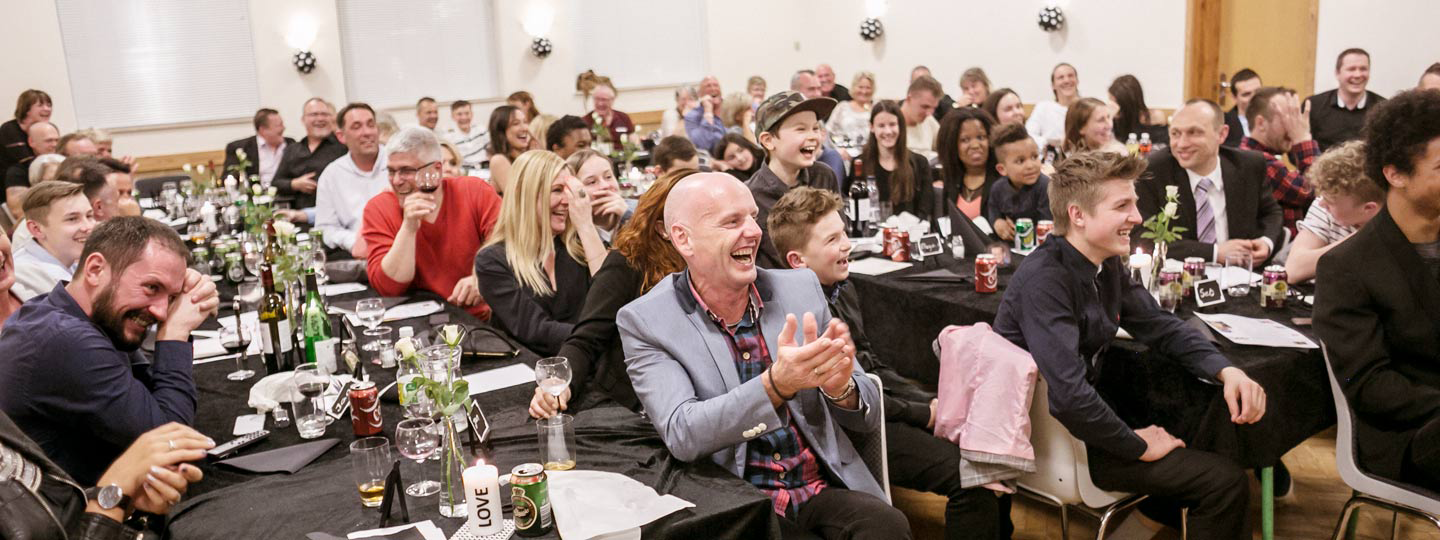

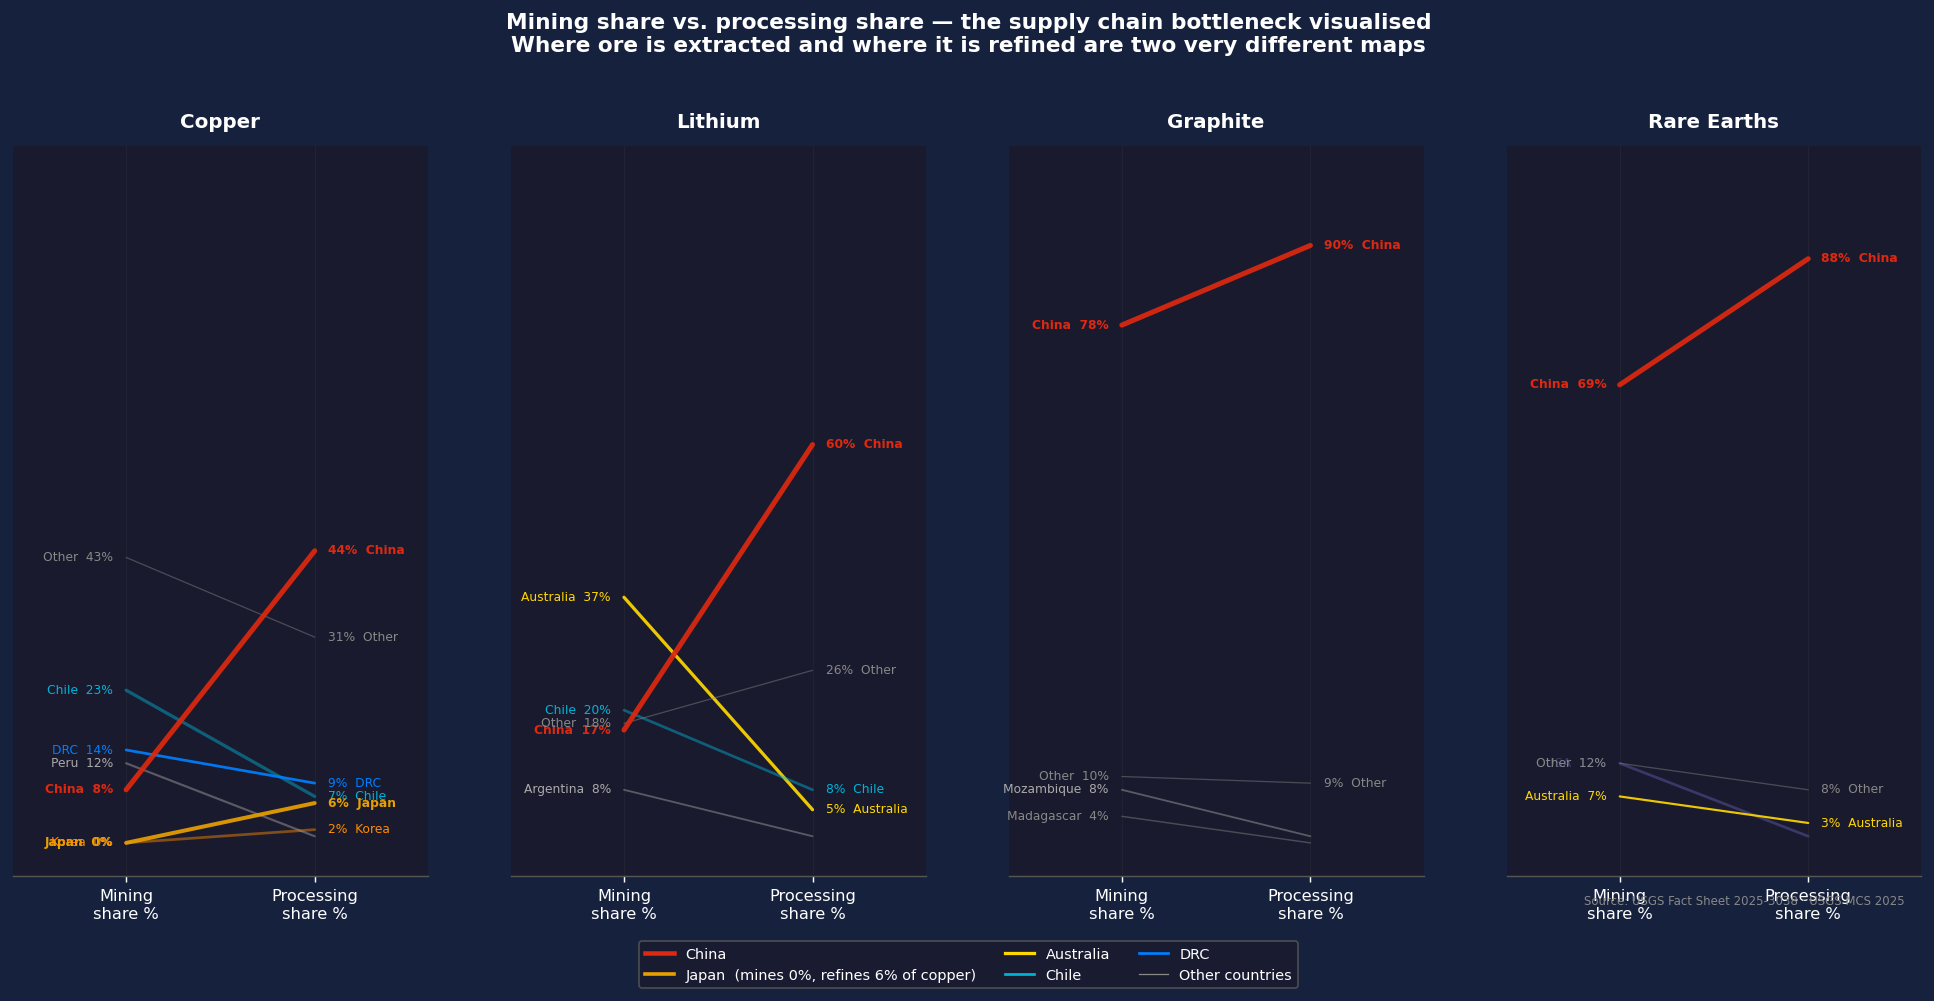

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Case 1 — Chart: Mining vs. Processing slope chart
# Visual punchline of the Type 1 trap: mining is distributed, processing is not.
# Japan and Korea highlighted as examples that capture refining without owning mines.
# Data: USGS Fact Sheet 2025-3038 + MCS 2025 narrative notes
# ─────────────────────────────────────────────────────────────────────────────

from matplotlib.lines import Line2D

JAPAN_COLOR = '#e8a000'

slope_data = {
    'Copper': [
        ('China',      8,  44, CHINA_RED,    2.8),
        ('Chile',     23,   7, '#00b4d8',    1.8),
        ('DRC',       14,   9, DRC_BLUE,     1.5),
        ('Peru',      12,   1, '#aaaaaa',    1.2),
        ('Japan',      0,   6, JAPAN_COLOR,  2.2),
        ('Korea',      0,   2, '#FF8C00',    1.5),
        ('Other',     43,  31, MUTED,        0.7),
    ],
    'Lithium': [
        ('China',     17,  60, CHINA_RED,    2.8),
        ('Australia', 37,   5, AUS_GOLD,     1.8),
        ('Chile',     20,   8, '#00b4d8',    1.5),
        ('Argentina',  8,   1, '#aaaaaa',    1.0),
        ('Other',     18,  26, MUTED,        0.7),
    ],
    'Graphite': [
        ('China',     78,  90, CHINA_RED,    2.8),
        ('Mozambique', 8,   1, '#aaaaaa',    1.0),
        ('Madagascar', 4,   0, '#888888',    0.8),
        ('Other',     10,   9, MUTED,        0.7),
    ],
    'Rare Earths': [
        ('China',     69,  88, CHINA_RED,    2.8),
        ('USA',       12,   1, '#3C3B6E',    1.5),
        ('Australia',  7,   3, AUS_GOLD,     1.2),
        ('Other',     12,   8, MUTED,        0.7),
    ],
}

fig, axes = plt.subplots(1, 4, figsize=(15, 7))
fig.patch.set_facecolor(DARK_BG)

for ax, (mineral, entries) in zip(axes, slope_data.items()):
    ax.set_facecolor(PANEL_BG)

    for country, mining, processing, color, lw in entries:
        is_featured = color in (CHINA_RED, JAPAN_COLOR, AUS_GOLD, '#3C3B6E', DRC_BLUE)
        alpha = 0.92 if is_featured else 0.45
        zorder = 4 if color == CHINA_RED else (3 if color == JAPAN_COLOR else 2)

        ax.plot([0, 1], [mining, processing],
                color=color, linewidth=lw, alpha=alpha,
                solid_capstyle='round', zorder=zorder)

        if mining >= 4 or country in ('Japan', 'Korea'):
            ax.text(-0.07, mining, f'{country}  {mining}%',
                    ha='right', va='center', fontsize=6.8, color=color,
                    fontweight='bold' if color in (CHINA_RED, JAPAN_COLOR) else 'normal')

        if processing >= 2 or country in ('Japan', 'Korea'):
            ax.text(1.07, processing, f'{processing}%  {country}',
                    ha='left', va='center', fontsize=6.8, color=color,
                    fontweight='bold' if color in (CHINA_RED, JAPAN_COLOR) else 'normal')

    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(-5, 105)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Mining\nshare %', 'Processing\nshare %'], fontsize=9, color='white')
    ax.set_title(mineral, fontsize=11, fontweight='bold', pad=10, color='white')
    ax.tick_params(left=False)
    ax.set_yticks([])
    for spine in ['left', 'right', 'top']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#555')

legend_elements = [
    Line2D([0], [0], color=CHINA_RED,    lw=2.5, label='China'),
    Line2D([0], [0], color=JAPAN_COLOR,  lw=2.0, label='Japan  (mines 0%, refines 6% of copper)'),
    Line2D([0], [0], color=AUS_GOLD,     lw=1.8, label='Australia'),
    Line2D([0], [0], color='#00b4d8',    lw=1.5, label='Chile'),
    Line2D([0], [0], color=DRC_BLUE,     lw=1.5, label='DRC'),
    Line2D([0], [0], color=MUTED,        lw=0.7, label='Other countries'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           facecolor=PANEL_BG, edgecolor='#555', fontsize=8,
           bbox_to_anchor=(0.5, -0.06))

fig.suptitle(
    'Mining share vs. processing share — the supply chain bottleneck visualised\n'
    'Where ore is extracted and where it is refined are two very different maps',
    fontsize=12, fontweight='bold', color='white', y=1.02)
fig.text(0.98, 0.04, 'Source: USGS Fact Sheet 2025-3038 · USGS MCS 2025',
         ha='right', fontsize=6.5, color=MUTED)
plt.tight_layout(w_pad=3)
plt.show()


---
## Case 2: Scarce and Captured
### *When the geology itself is the lock*

For a second group of materials, there is no processing bottleneck to unblock and no industrial catch-up to pursue. The ore itself is rare, and its rarity is a well-known geological fact. These minerals do not occur in most of the world's rock — they form only under specific geological conditions that have played out in a handful of places on Earth. Whoever sits on those places holds the leverage, regardless of what happens downstream.

**Cobalt** is the clearest example. The Democratic Republic of Congo accounts for approximately 76% of global cobalt mine production - a consequence of the unique mineralogy of the Central African Copperbelt, a stratiform geological formation with no confirmed equivalent at comparable scale anywhere else. This is not policy or industrial choice; it is geography. What compounds the challenge is a structural decoupling: the country that holds the ore does not control its refinement. Cobalt leaves the DRC as partially processed material and is refined elsewhere, meaning the ore-holder captures the extraction risk while others capture the finished product value.

**Heavy rare earth elements** — Dysprosium and Terbium — present a related but distinct case. The geological formations that contain these elements in practically extractable form are themselves geographically rare. Ion-adsorption clay deposits, the specific laterite type that makes heavy REE recovery feasible at industrial scale, require millions of years of specific tropical weathering to develop. Outside the regions where those conditions existed, the formations did not form. Even full refining capacity built elsewhere would still require ore sourced from the same narrow geography.

**Platinum** illustrates the category from a different angle: the Bushveld Igneous Complex in South Africa holds roughly 80% of global platinum reserves — a permanent geological fact. But here, unlike cobalt, the country that holds the ore largely controls its processing too. This makes it a case of geological concentration that has not produced the same kind of external vulnerability, and a useful reminder that Type 2 does not automatically mean supply insecurity - only that the leverage is geological rather than industrial.

For Type 2 materials, the honest policy response is not "build more refining capacity." It is: stockpile, invest in material substitution, and accept managed dependence where no alternative exists.


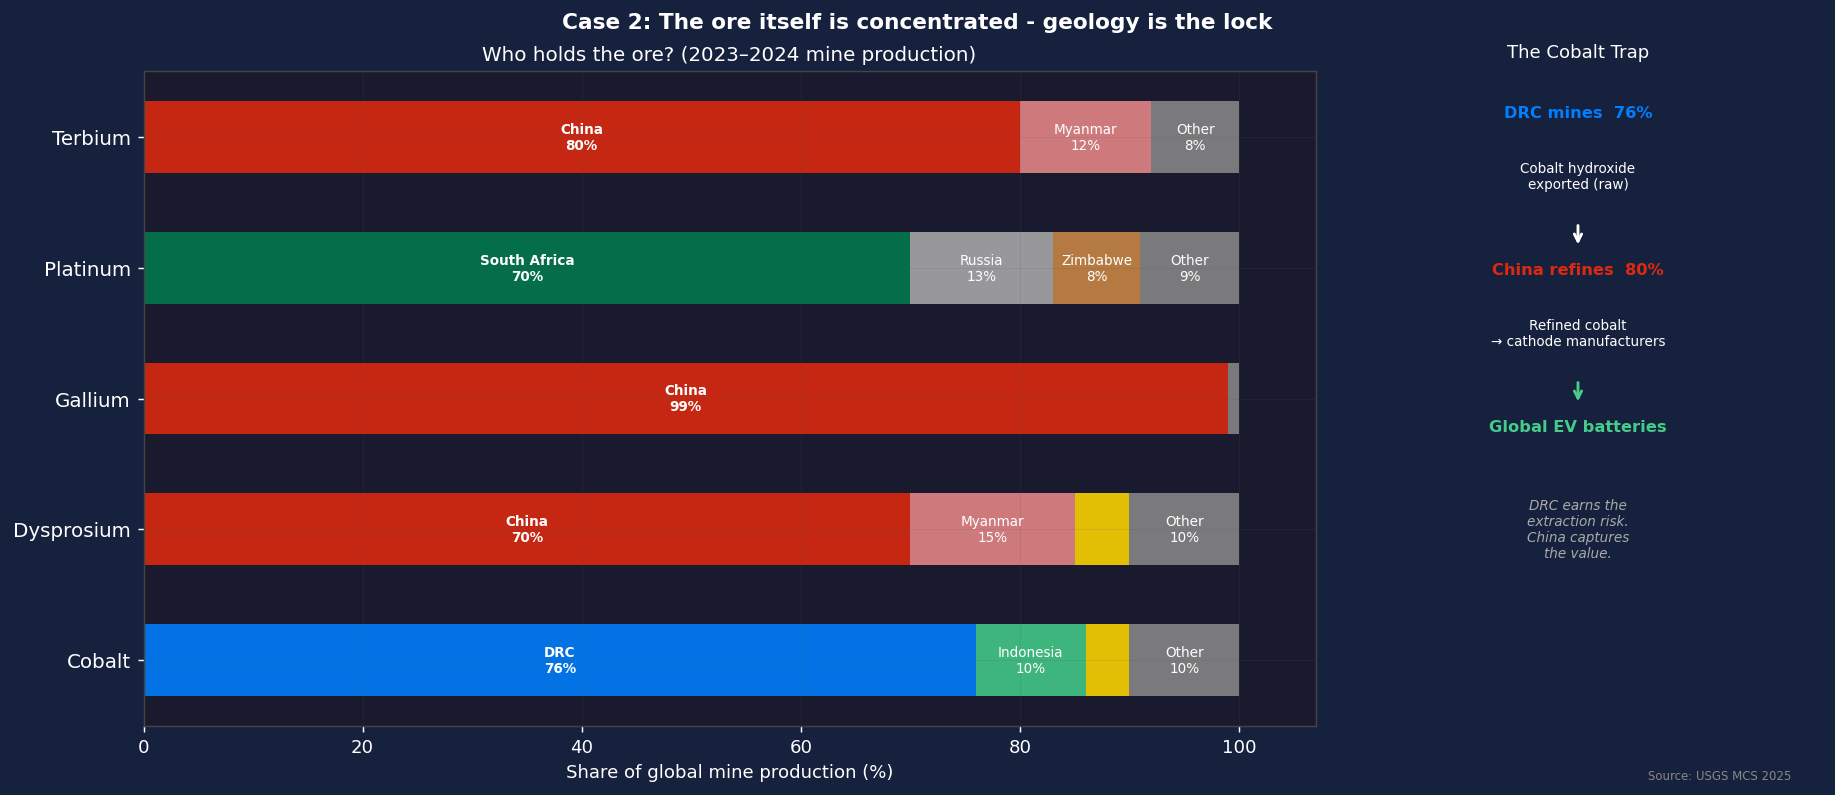

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Case 2 — Chart: Mining concentration for scarce-and-captured minerals
# Left panel: stacked horizontal bars — who holds the ore?
# Right callout: The cobalt trap — DRC mines, China refines
# Data: USGS MCS 2025 (updated 2024 figures)
# ─────────────────────────────────────────────────────────────────────────────

type2_data = {
    'Cobalt':     [('DRC', 76, DRC_BLUE), ('Indonesia', 10, '#44cc88'), ('Australia', 4, AUS_GOLD), ('Other', 10, MUTED)],
    'Dysprosium': [('China', 70, CHINA_RED), ('Myanmar', 15, '#e88888'), ('Australia', 5, AUS_GOLD), ('Other', 10, MUTED)],
    'Gallium':    [('China', 99, CHINA_RED), ('Other', 1, MUTED)],
    'Platinum':   [('South Africa', 70, SA_GREEN), ('Russia', 13, '#aaaaaa'), ('Zimbabwe', 8, '#cc8844'), ('Other', 9, MUTED)],
    'Terbium':    [('China', 80, CHINA_RED), ('Myanmar', 12, '#e88888'), ('Other', 8, MUTED)],
}

fig = plt.figure(figsize=(14, 6), constrained_layout=True)
fig.patch.set_facecolor(DARK_BG)
gs = fig.add_gridspec(1, 2, width_ratios=[3, 1.25])
ax_bars   = fig.add_subplot(gs[0])
ax_cobalt = fig.add_subplot(gs[1])

# ── Left: stacked bars ──────────────────────────────────────────────────────
minerals_order = list(type2_data.keys())
for mineral, entries in type2_data.items():
    y_idx  = minerals_order.index(mineral)
    bottom = 0
    for country, share, color in entries:
        ax_bars.barh(y_idx, share, left=bottom, height=0.55, color=color, alpha=0.88)
        if share >= 7:
            txt_color = 'black' if color == AUS_GOLD else 'white'
            ax_bars.text(bottom + share / 2, y_idx,
                         f'{country}\n{share}%',
                         ha='center', va='center', fontsize=7.5,
                         fontweight='bold' if share >= 50 else 'normal',
                         color=txt_color)
        bottom += share

ax_bars.set_yticks(range(len(minerals_order)))
ax_bars.set_yticklabels(minerals_order, fontsize=11)
ax_bars.set_xlim(0, 107)
ax_bars.set_xlabel("Share of global mine production (%)")
ax_bars.set_title("Who holds the ore? (2023–2024 mine production)", fontsize=11)

# ── Right: Cobalt DRC trap ──────────────────────────────────────────────────
ax_cobalt.set_facecolor(PANEL_BG)
ax_cobalt.set_xlim(0, 10)
ax_cobalt.set_ylim(0, 10)
ax_cobalt.axis('off')

def arrow(ax, x1, y1, x2, y2, color):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.6,
                                connectionstyle='arc3,rad=0'))

# Layout (top → bottom):
#   y=9.3  Node 1: DRC mines
#   y=8.4  Connector: cobalt hydroxide description
#            ↓ arrow  7.7 → 7.3
#   y=6.9  Node 2: China refines
#   y=6.0  Connector: refined cobalt description
#            ↓ arrow  5.3 → 4.9
#   y=4.5  Node 3: Global EV batteries
#   y=3.0  Italic note

ax_cobalt.text(5, 9.3, 'DRC mines  76%',
               ha='center', fontsize=9, color=DRC_BLUE, fontweight='bold')
ax_cobalt.text(5, 8.4, 'Cobalt hydroxide\nexported (raw)',
               ha='center', va='center', fontsize=7.5, color='white')

arrow(ax_cobalt, 5, 7.7, 5, 7.3, 'white')

ax_cobalt.text(5, 6.9, 'China refines  80%',
               ha='center', fontsize=9, color=CHINA_RED, fontweight='bold')
ax_cobalt.text(5, 6.0, 'Refined cobalt\n→ cathode manufacturers',
               ha='center', va='center', fontsize=7.5, color='white')

arrow(ax_cobalt, 5, 5.3, 5, 4.9, '#44cc88')

ax_cobalt.text(5, 4.5, 'Global EV batteries',
               ha='center', fontsize=9, color='#44cc88', fontweight='bold')
ax_cobalt.text(5, 3.0,
               'DRC earns the\nextraction risk.\nChina captures\nthe value.',
               ha='center', va='center', fontsize=7.5, color='#aaaaaa', style='italic')

ax_cobalt.set_title('The Cobalt Trap', fontsize=10, color='white', pad=8)

fig.suptitle('Case 2: The ore itself is concentrated - geology is the lock',
             fontsize=12, fontweight='bold')
fig.text(0.98, 0.01, 'Source: USGS MCS 2025', ha='right', fontsize=6.5, color=MUTED)
plt.show()


---
## Case 3: Abundant but Hard to Get
### *The ore is everywhere. The process is the barrier.*

A third structural type applies to materials where neither geology nor geopolitics is the primary constraint. Deposits are found in many countries, no single actor holds a monopoly on reserves, and the Type 1 or Type 2 dynamics of processing capture or geological scarcity do not apply in the same way. The barrier here is purely technical and economic: converting these ores into a grade usable in batteries, magnets, or semiconductors is so demanding, so energy-intensive, and so expensive that even without political barriers, practical supply remains limited.

**Graphite** is mapped in Mozambique, Madagascar, Brazil, Canada, and across Asia - a genuinely distributed geological resource. But the battery industry requires carbon at 99.95% purity, far above the 85–92% found in natural flake ore. Reaching that purity requires either furnace temperatures above 3000°C or aggressive chemical purification. Both demand specialized, purpose-built industrial plants. The process is not secret - it is hard and expensive, and that difficulty alone has kept production highly concentrated even as ore availability is not.

**Lithium** is mined on three continents. But turning lithium ore into battery-grade lithium hydroxide (the specific chemical form required by high-energy-density cathodes) requires high-temperature roasting, acid leaching, and multiple precision crystallisation stages. The process chemistry is understood; the challenge is that building the integrated industrial plants to do it at scale and competitive cost takes a decade and substantial capital. Many countries hold ore; very few hold the processing infrastructure.

**Rare earth separation** illustrates the most technically extreme version of this barrier. Even where ore deposits exist locally, separating a single rare earth element from a mixed concentrate requires hundreds of sequential solvent extraction stages — one of the most complex industrial chemical processes in routine production. The rare earth elements have nearly identical chemical properties, and isolating each from the others is not a matter of simply scaling up a simple reaction. Getting from raw ore to 99.5% pure Nd₂O₃ for a motor magnet represents a manufacturing challenge of the first order, and the price premium for doing so reflects it.

The charts below capture these barriers in price terms: the rare earth separation value cliff — where the same ore body yields materials ranging from $1/kg to $810/kg depending on which element is isolated - and the price history of 2020–2024, when refining capacity for lithium and rare earths could not keep pace with demand.

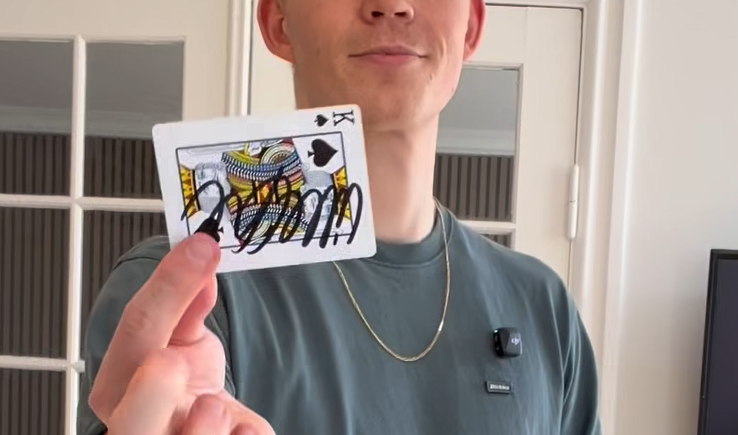

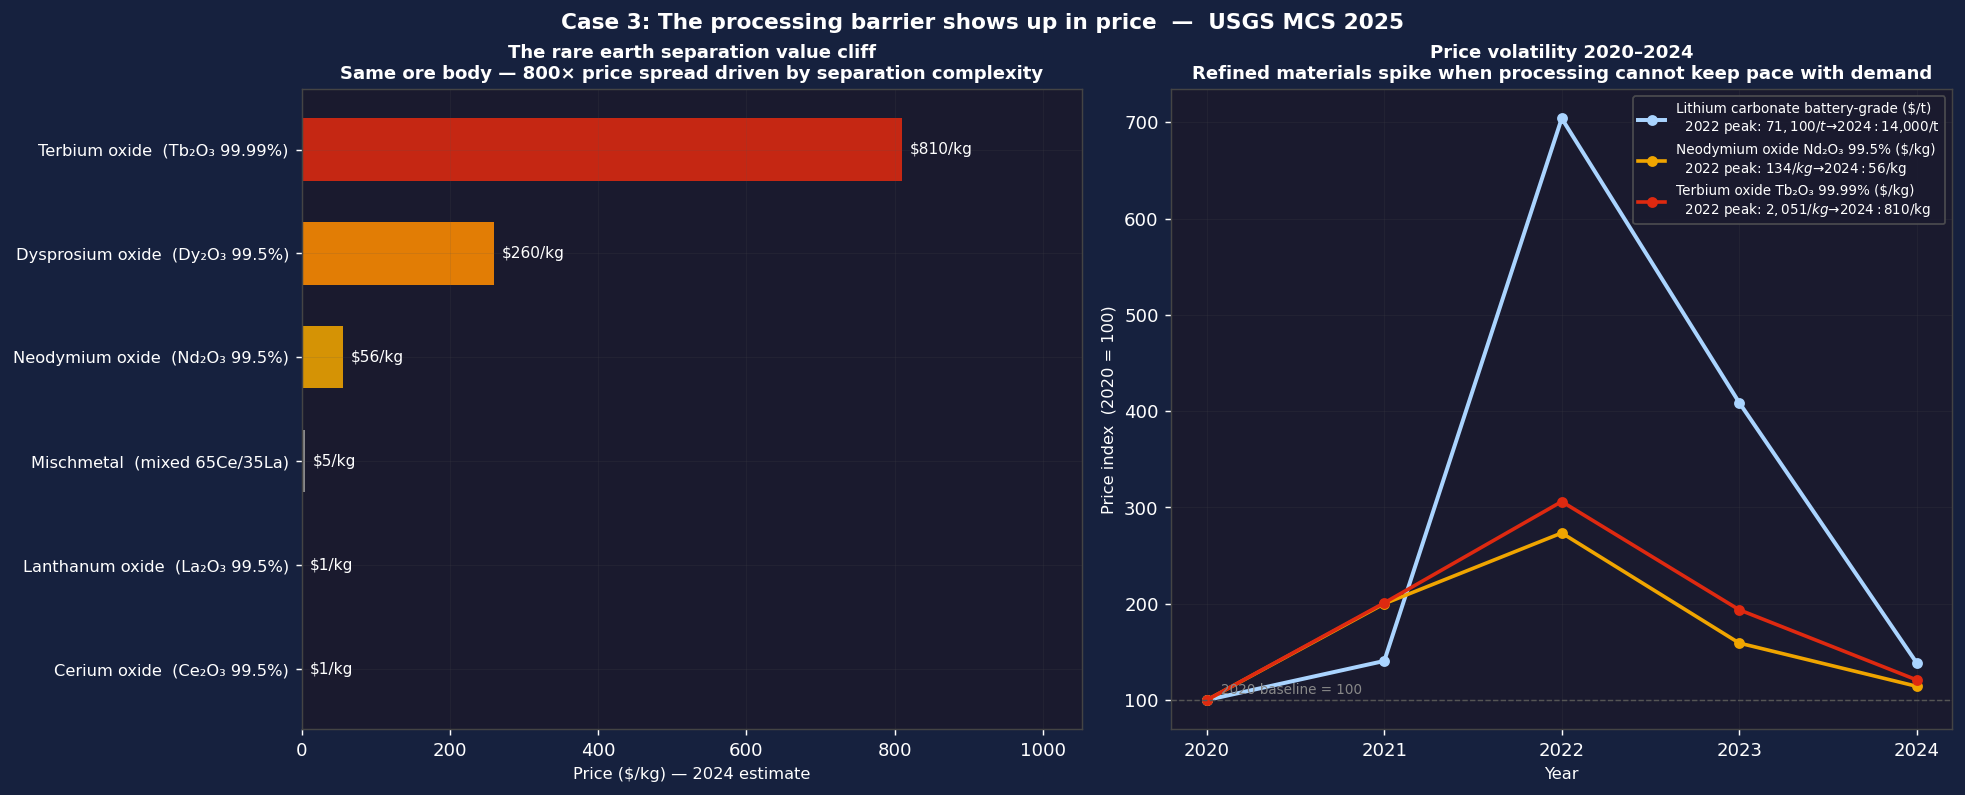

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Case 3 — Charts: The processing barrier in price terms
# All values read directly from mcs2025_all_prices.csv (USGS MCS 2025)
# ─────────────────────────────────────────────────────────────────────────────

df_prices = pd.read_csv(RAW / 'D+ USGS MCS 2025' / 'mcs2025_all_prices.csv', comment='#')

# ── Chart A: REE separation value ladder ─────────────────────────────────────
ree_minerals = [
    'Cerium oxide 99.5%',
    'Lanthanum oxide 99.5%',
    'Mischmetal 65Ce/35La',
    'Neodymium oxide 99.5%',
    'Dysprosium oxide 99.5%',
    'Terbium oxide 99.99%',
]
ree_display = [
    'Cerium oxide  (Ce₂O₃ 99.5%)',
    'Lanthanum oxide  (La₂O₃ 99.5%)',
    'Mischmetal  (mixed 65Ce/35La)',
    'Neodymium oxide  (Nd₂O₃ 99.5%)',
    'Dysprosium oxide  (Dy₂O₃ 99.5%)',
    'Terbium oxide  (Tb₂O₃ 99.99%)',
]
ree_colors = ['#666666', '#777777', '#999999', ACCENT, '#ff8c00', CHINA_RED]

df_ree = df_prices[df_prices['mineral'].isin(ree_minerals)][['mineral', '2024e']].copy()
df_ree = df_ree.sort_values('2024e').reset_index(drop=True)

display_map   = dict(zip(ree_minerals, ree_display))
color_map     = dict(zip(ree_minerals, ree_colors))
sorted_labels = [display_map[m] for m in df_ree['mineral']]
sorted_colors = [color_map[m]   for m in df_ree['mineral']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
fig.patch.set_facecolor(DARK_BG)

ax = axes[0]
bars = ax.barh(range(len(df_ree)), df_ree['2024e'], color=sorted_colors, height=0.6, alpha=0.88)
ax.set_yticks(range(len(df_ree)))
ax.set_yticklabels(sorted_labels, fontsize=9)
ax.set_xlabel('Price ($/kg) — 2024 estimate', fontsize=9)
ax.set_title(
    'The rare earth separation value cliff\n'
    'Same ore body — 800× price spread driven by separation complexity',
    fontsize=10, fontweight='bold'
)
for bar, val in zip(bars, df_ree['2024e']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'${val:,}/kg', va='center', fontsize=8.5, color='white')
ax.set_xlim(0, df_ree['2024e'].max() * 1.3)

# ── Chart B: Price index 2020–2024 ───────────────────────────────────────────
years_str   = ['2020', '2021', '2022', '2023', '2024e']
year_labels = [2020, 2021, 2022, 2023, 2024]

def price_series(mineral):
    row = df_prices[df_prices['mineral'] == mineral]
    return [float(row[y].values[0]) for y in years_str]

li = price_series('Lithium carbonate battery-grade')
nd = price_series('Neodymium oxide 99.5%')
tb = price_series('Terbium oxide 99.99%')

def to_index(series):
    return [v / series[0] * 100 for v in series]

ax = axes[1]
ax.plot(year_labels, to_index(li), color='#aad4ff', lw=2.2, marker='o', markersize=5,
        label=f'Lithium carbonate battery-grade ($/t)\n  2022 peak: ${li[2]:,.0f}/t  →  2024: ${li[4]:,.0f}/t')
ax.plot(year_labels, to_index(nd), color=ACCENT, lw=2.0, marker='o', markersize=5,
        label=f'Neodymium oxide Nd₂O₃ 99.5% ($/kg)\n  2022 peak: ${nd[2]:,.0f}/kg  →  2024: ${nd[4]:,.0f}/kg')
ax.plot(year_labels, to_index(tb), color=CHINA_RED, lw=2.0, marker='o', markersize=5,
        label=f'Terbium oxide Tb₂O₃ 99.99% ($/kg)\n  2022 peak: ${tb[2]:,.0f}/kg  →  2024: ${tb[4]:,.0f}/kg')
ax.axhline(100, color='#555', lw=0.8, linestyle='--')
ax.text(2020.08, 106, '2020 baseline = 100', fontsize=7.5, color='#888')
ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel('Price index  (2020 = 100)', fontsize=9)
ax.set_title(
    'Price volatility 2020–2024\n'
    'Refined materials spike when processing cannot keep pace with demand',
    fontsize=10, fontweight='bold'
)
ax.legend(fontsize=7.5, facecolor=PANEL_BG, edgecolor='#555', loc='upper right')
ax.set_xticks(year_labels)

fig.suptitle('Case 3: The processing barrier shows up in price  —  USGS MCS 2025',
             fontsize=12, fontweight='bold')
plt.show()
